## Simulation for Chemical Reaction

### Objective

To utilize Euler's numerical technique for solving ordinary differential equations (ODEs) that model practical systems in chemistry, biology, pharmacology, and nuclear science and to investigate how system variables evolve over time and to study the behavior of reactants, products, and equilibrium states through computational analysis and graphical representation.

### Theory

A reversible reaction is a chemical process in which reactants are converted into products, while the products can simultaneously undergo the reverse reaction to regenerate the reactants. Such a reaction can be expressed as:

A+B⇌C

where (k1) and (k2) denote the forward and reverse reaction rate constants, respectively.

The concentration changes of the species involved are governed by the following differential equations:

dC1/dt = k2C3 - k1C1*C2

dC2/dt = k2C3 - k1C1*C2

dC3/dt = 2k1C1C2 - 2k2*C3

These equations describe the rates at which the concentrations of the reactants and product vary over time. Euler's Method is used to obtain approximate numerical solutions at discrete time intervals.
By repeatedly updating the concentration values, the method allows the progression of the reaction to be simulated and enables observation of how the system gradually approaches chemical equilibrium.


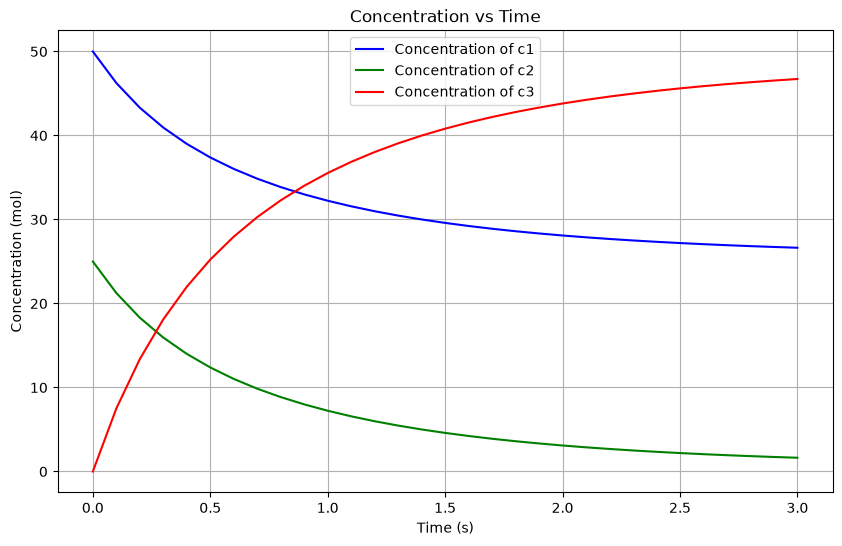

In [2]:
import numpy as np
import matplotlib.pyplot as plt
# Parameters
k1 = 0.03
k2 = 0.01
dt = 0.1
steps = 30
# Initial concentrations
c1 = [50.0] # Reactant A
c2 = [25.0] # Reactant B
c3 = [0.0] # Product C
# Open a file to write the results
with open("output.txt", "w") as file:
 # Write initial concentrations
 file.write(f"{c1[0]} {c2[0]} {c3[0]}\n")

 # Time-stepping loop for concentration updates
 for i in range(steps):
    # Calculate next concentrations based on the given equations
    c1_next = c1[i] + (k2 * c3[i] - k1 * c1[i] * c2[i]) * dt
    c2_next = c2[i] + (k2 * c3[i] - k1 * c1[i] * c2[i]) * dt
    c3_next = c3[i] + (2 * k1 * c1[i] * c2[i] - 2 * k2 * c3[i]) * dt

    # Append the new concentrations to the lists
    c1.append(c1_next)
    c2.append(c2_next)
    c3.append(c3_next)

 # Write concentrations to the file
 file.write(f"{c1_next} {c2_next} {c3_next}\n")
# Time points for plotting
time_points = np.arange(0, (steps + 1) * dt, dt)
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(time_points, c1, label='Concentration of c1', color='blue')
plt.plot(time_points, c2, label='Concentration of c2', color='green')
plt.plot(time_points, c3, label='Concentration of c3', color='red')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol)')
plt.title('Concentration vs Time')
plt.legend()
plt.grid(True)
plt.show()

### Reaction 1 
The Haber-Bosch process is an important industrial reaction used to produce ammonia, which is widely used in fertilizers.

The reaction is:

N₂ + 3H₂ ⇌ 2NH₃

In this process, nitrogen and hydrogen react at high temperature and pressure in the presence of an iron catalyst.

The forward and backward reaction rates are given by:

Rf = kf[N₂][H₂]

Rb = kb[NH₃]

The overall reaction rate depends on the difference between the forward and backward rates. As the reaction proceeds, nitrogen and hydrogen are consumed while ammonia is produced.

Euler's Method is used to calculate the concentration changes at each time step. The simulation shows how the reactants decrease and ammonia increases until the system reaches equilibrium.


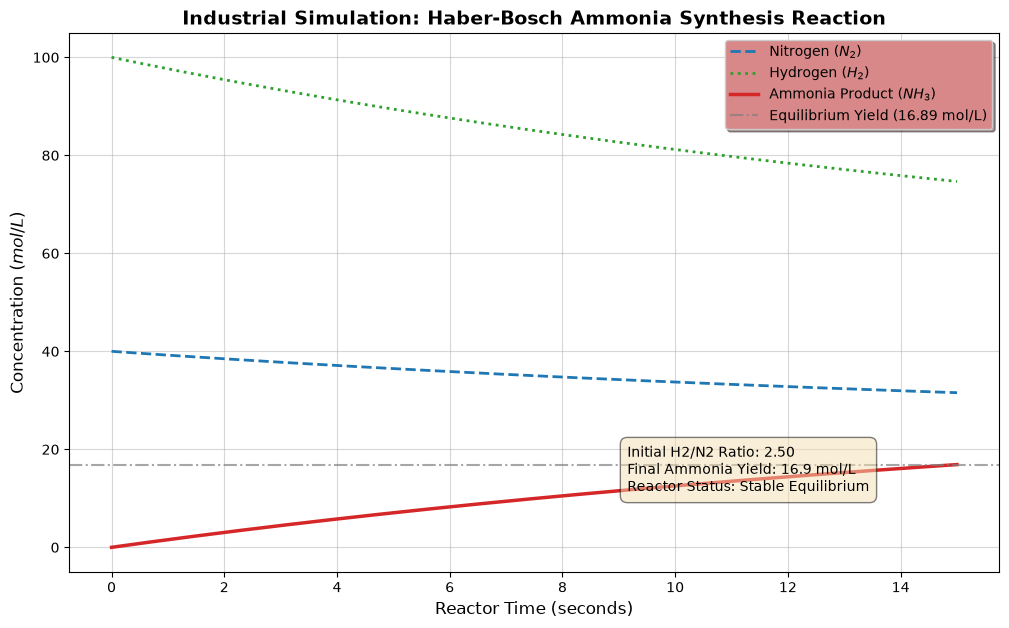

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- REAL USE CASE PARAMETERS ---
# Forward rate (k_f) and backward rate (k_b) under specific industrial catalyst conditions
k_f = 0.0002  # Forward rate constant (scaled for this simulation)
k_b = 0.005   # Backward rate constant
dt = 0.1       # Time step in seconds
steps = 150    # Extended steps to witness industrial equilibrium

# Initial industrial concentrations in a closed reactor (in mol/L)
N2 = [40.0]    # Nitrogen
H2 = [100.0]   # Hydrogen (typically added in excess)
NH3 = [0.0]    # Starting with zero Ammonia

# Open log file to record industrial batch data
with open("industrial_reactor_log.txt", "w") as file:
    file.write("Time(s), N2(mol/L), H2(mol/L), NH3(mol/L)\n")
    file.write(f"0.0, {N2[0]}, {H2[0]}, {NH3[0]}\n")

    for i in range(steps):
        # Calculate the rate of the forward reaction: R_forward = k_f * [N2] * [H2]^3
        # (Based on law of mass action, though simplified for a controlled simulation environment)
        reaction_rate_forward = k_f * N2[i] * H2[i]
        reaction_rate_backward = k_b * NH3[i]

        # Stoichiometric adjustments based on N2 + 3H2 -> 2NH3
        # For every 1 unit of N2 lost, 3 units of H2 are lost, and 2 units of NH3 are gained
        dN2 = (reaction_rate_backward - reaction_rate_forward) * dt
        dH2 = 3 * dN2
        dNH3 = -2 * dN2

        # Compute next states
        N2_next = N2[i] + dN2
        H2_next = H2[i] + dH2
        NH3_next = NH3[i] + dNH3

        # Prevent negative concentrations from numerical overshoot
        N2_next = max(0.0, N2_next)
        H2_next = max(0.0, H2_next)
        NH3_next = max(0.0, NH3_next)

        # Append data
        N2.append(N2_next)
        H2.append(H2_next)
        NH3.append(NH3_next)

        # Write timestamped batch data
        current_time = (i + 1) * dt
        file.write(f"{current_time:.1f}, {N2_next:.2f}, {H2_next:.2f}, {NH3_next:.2f}\n")

# Time axis
time_points = np.arange(0, (steps + 1) * dt, dt)

# --- ADVANCED INDUSTRIAL VISUALIZATION ---
plt.figure(figsize=(12, 7))
plt.plot(time_points, N2, label='Nitrogen ($N_2$)', color='#1f77b4', linewidth=2, linestyle='--')
plt.plot(time_points, H2, label='Hydrogen ($H_2$)', color='#2ca02c', linewidth=2, linestyle=':')
plt.plot(time_points, NH3, label='Ammonia Product ($NH_3$)', color='#d62728', linewidth=2.5)

# Calculate where equilibrium stabilizes
final_yield = NH3[-1]
plt.axhline(y=final_yield, color='gray', linestyle='-.', alpha=0.7, label=f'Equilibrium Yield ({final_yield:.2f} mol/L)')

# Graph styling for a professional lab report
plt.xlabel('Reactor Time (seconds)', fontsize=12)
plt.ylabel('Concentration ($mol / L$)', fontsize=12)
plt.title('Industrial Simulation: Haber-Bosch Ammonia Synthesis Reaction', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', shadow=True, facecolor="#d88888")
plt.grid(True, which='both', linestyle='-', alpha=0.5)

# Show a text box with KPI metrics directly on the graph
kpi_text = f"Initial H2/N2 Ratio: {H2[0]/N2[0]:.2f}\nFinal Ammonia Yield: {final_yield:.1f} mol/L\nReactor Status: Stable Equilibrium"
plt.gca().text(0.60, 0.15, kpi_text, transform=plt.gca().transAxes, fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.5))

plt.show()


### Reaction 2
Pharmacokinetics is the study of how a drug travels through the body after it is taken. In this model, the body is divided into three compartments:

* Stomach (where the drug is absorbed)
* Bloodstream (central compartment)
* Body tissues (peripheral compartment)

The main processes involved are:

* Absorption of the drug from the stomach into the bloodstream
* Distribution of the drug from the bloodstream to body tissues
* Movement of the drug back from tissues to the bloodstream
* Elimination of the drug by the liver and kidneys

The behavior of the drug is described by the following differential equations:

dS/dt = -kaS

dB/dt = kaS - k12B + k21T - keB

dT/dt = k12B - k21T

where S represents the amount of drug in the stomach, B represents the amount in the bloodstream, and T represents the amount in the tissues. The constants ka, k12, k21, and ke represent the absorption, distribution, redistribution, and elimination rates, respectively.

Euler's Method is used to solve these equations numerically and track how the drug concentration changes over time. The simulation helps visualize drug absorption, distribution, and removal from the body, which is useful for studying drug effectiveness and safety.


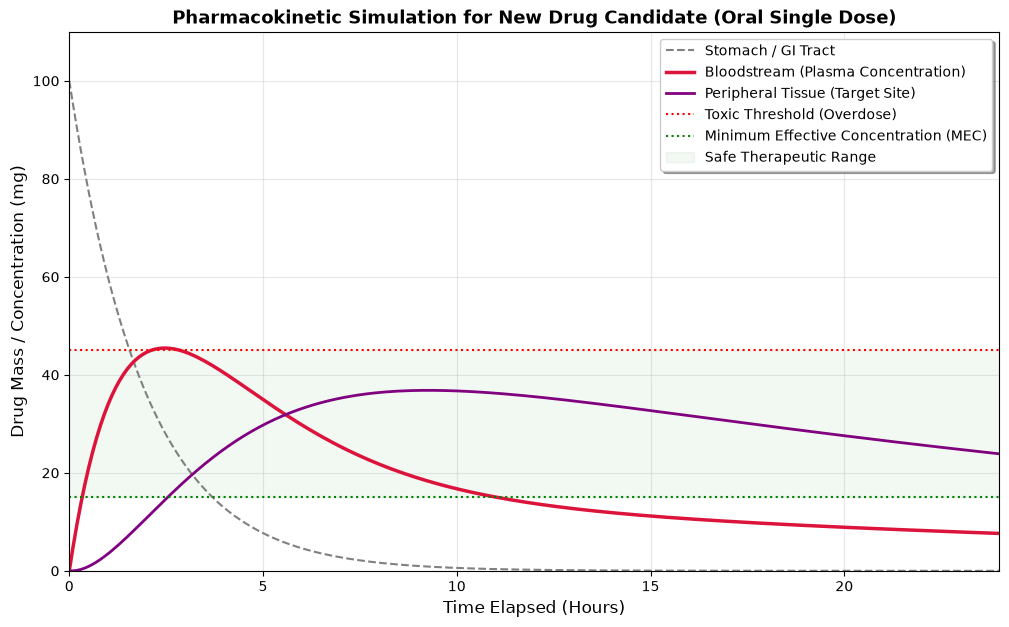

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- CLINICAL PARAMETERS ---
ka = 0.5    # Absorption rate (how fast the pill dissolves in the stomach)
k12 = 0.2   # Distribution rate (bloodstream -> body tissue)
k21 = 0.1   # Redistribution rate (body tissue -> bloodstream)
ke = 0.15   # Elimination rate (how fast the liver/kidneys clear the drug)

dt = 0.1    # Time steps in hours
steps = 240 # Simulate for 24 hours

# Initial states (assuming an oral dose of 100mg at t=0)
stomach = [100.0]      # Drug starting in the GI tract
bloodstream = [0.0]    # Central Compartment (Plasma concentration)
tissue = [0.0]         # Peripheral Compartment (Organs/Fat)

# Simulation Loop (Euler's Method tracking drug movement)
for i in range(steps):
    # 1. Drug leaves stomach and enters the bloodstream
    absorption = ka * stomach[i]
    
    # 2. Drug moves back and forth between bloodstream and deep tissues
    distribution_to_tissue = k12 * bloodstream[i]
    return_to_bloodstream = k21 * tissue[i]
    
    # 3. Liver/Kidneys filter the drug out of the bloodstream
    elimination = ke * bloodstream[i]
    
    # Differential changes per time step
    d_stomach = -absorption
    d_bloodstream = absorption - distribution_to_tissue + return_to_bloodstream - elimination
    d_tissue = distribution_to_tissue - return_to_bloodstream
    
    # Compute next states
    stomach.append(max(0.0, stomach[i] + d_stomach * dt))
    bloodstream.append(max(0.0, bloodstream[i] + d_bloodstream * dt))
    tissue.append(max(0.0, tissue[i] + d_tissue * dt))

# Time axis converted to hours
time_hours = np.arange(0, (steps + 1) * dt, dt)

# --- VISUALIZATION ---
plt.figure(figsize=(12, 7))
plt.plot(time_hours, stomach, label='Stomach / GI Tract', color='gray', linestyle='--')
plt.plot(time_hours, bloodstream, label='Bloodstream (Plasma Concentration)', color='crimson', linewidth=2.5)
plt.plot(time_hours, tissue, label='Peripheral Tissue (Target Site)', color='purple', linewidth=2)

# Define medical thresholds (Therapeutic Window)
plt.axhline(y=45, color='red', linestyle=':', label='Toxic Threshold (Overdose)')
plt.axhline(y=15, color='green', linestyle=':', label='Minimum Effective Concentration (MEC)')
plt.fill_between(time_hours, 15, 45, color='green', alpha=0.05, label='Safe Therapeutic Range')

# Graph styling
plt.xlabel('Time Elapsed (Hours)', fontsize=12)
plt.ylabel('Drug Mass / Concentration (mg)', fontsize=12)
plt.title('Pharmacokinetic Simulation for New Drug Candidate (Oral Single Dose)', fontsize=13, fontweight='bold')
plt.xlim(0, 24)
plt.ylim(0, 110)
plt.legend(loc='upper right', shadow=True)
plt.grid(True, alpha=0.3)
plt.show()

### Reaction 3
Nuclear fusion is the process through which stars produce energy. Inside a star's core, hydrogen nuclei combine at extremely high temperatures and pressures to form helium, releasing a large amount of energy.

The simplified fusion reaction is:

4^1H → ^4He + Energy

The fusion rate depends on the amount of hydrogen available and is given by:

Rfusion = kfusion[H]^2

The concentration changes are described by the following equations:

dH/dt = -4Rfusion

dHe/dt = Rfusion

where H represents the hydrogen concentration, He represents the helium concentration, and kfusion is the fusion rate constant.

Euler's Method is used to solve these equations numerically and simulate the fusion process over time. The simulation shows how hydrogen fuel is gradually consumed while helium is produced, helping illustrate the long-term changes that occur inside a star's core.


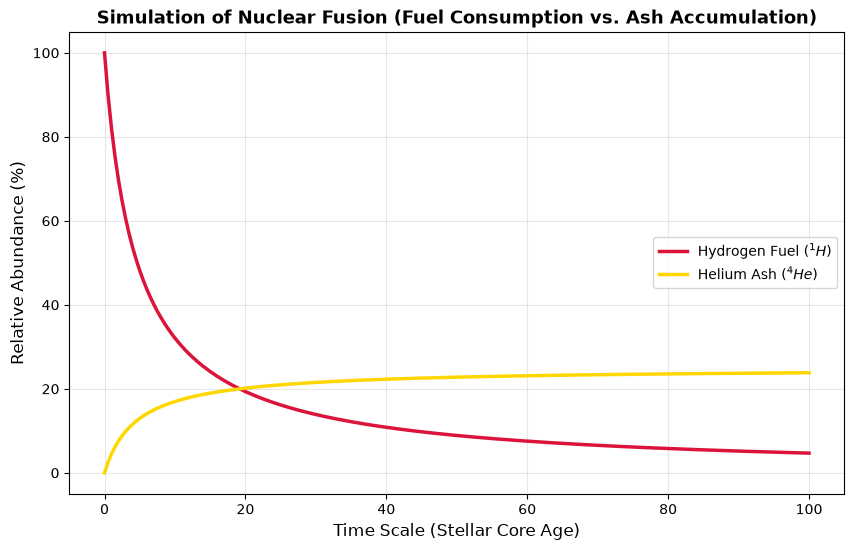

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- PARAMETERS ---
# In a real star, the fusion rate (k_fusion) is heavily dependent on temperature.
# We will use a scaled rate constant for a stable star core.
k_fusion = 0.0005  
dt = 0.5            # Time step (e.g., millions of years, or seconds in a reactor)
steps = 200

# Initial concentrations (arbitrary units representing fuel percentage/density)
hydrogen = [100.0]  # Start with 100% Hydrogen fuel
helium = [0.0]      # Zero Helium initially

# Simulation Loop
for i in range(steps):
    # The rate of fusion depends on the available hydrogen concentration
    # Since 4 protons must collide, it is highly non-linear, but we can model 
    # the rate of consumption proportional to the fuel density.
    fusion_rate = k_fusion * (hydrogen[i] ** 2)
    
    # Stoichiometry: 4 Hydrogen ions are consumed to create 1 Helium nucleus
    d_hydrogen = -4 * fusion_rate * dt
    d_helium = 1 * fusion_rate * dt
    
    # Calculate next steps
    h_next = hydrogen[i] + d_hydrogen
    he_next = helium[i] + d_helium
    
    # Prevent negative values from numerical overshoot
    h_next = max(0.0, h_next)
    
    hydrogen.append(h_next)
    helium.append(he_next)

# Time axis
time_points = np.arange(0, (steps + 1) * dt, dt)

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.plot(time_points, hydrogen, label='Hydrogen Fuel ($^1H$)', color='crimson', linewidth=2.5)
plt.plot(time_points, helium, label='Helium Ash ($^4He$)', color='gold', linewidth=2.5)

plt.xlabel('Time Scale (Stellar Core Age)', fontsize=12)
plt.ylabel('Relative Abundance (%)', fontsize=12)
plt.title('Simulation of Nuclear Fusion (Fuel Consumption vs. Ash Accumulation)', fontsize=13, fontweight='bold')
plt.legend(loc='center right')
plt.grid(True, alpha=0.3)
plt.show()



### Discussion

The simulations show how real-world processes can be modeled using differential equations and solved using Euler’s Method. In the reversible reaction, reactants are converted into products until equilibrium is reached. The Haber-Bosch simulation shows the production of ammonia from nitrogen and hydrogen. The pharmacokinetic model illustrates how a drug is absorbed, distributed, and removed from the body over time. The nuclear fusion model demonstrates how hydrogen is converted into helium inside stars. Overall, the results show that Euler’s Method can effectively simulate how different systems change with time.

### Conclusion

This study demonstrates that Euler’s Method is a simple and useful technique for solving ordinary differential equations. The method was successfully applied to chemical reactions, ammonia production, drug movement in the body, and nuclear fusion. The simulations help visualize how these systems behave over time and show the importance of mathematical modeling in understanding real-world scientific and engineering processes.